# Checkpoint 04 - Classificação de Imagens: Homer vs Bart Simpson

## 1. Definição do Problema
O objetivo deste projeto é desenvolver uma Rede Neural Convolucional (CNN) para realizar a classificação binária entre Homer Simpson e Bart Simpson. Utilizamos Transfer Learning com MobileNetV2 para garantir alta precisão mesmo com um volume menor de dados.

---

## 2. Pré-processamento das Imagens
Nesta etapa, realizamos a extração dos dados e a configuração do `ImageDataGenerator`. Aplicamos **Data Augmentation** para tornar o modelo mais robusto.

In [1]:
# Descompacta o arquivo zip direto no Colab
!unzip /content/dataset_personagens.zip -d /content/

Archive:  /content/dataset_personagens.zip
   creating: /content/dataset_personagens/
  inflating: /content/dataset_personagens/.DS_Store  
   creating: /content/__MACOSX/
   creating: /content/__MACOSX/dataset_personagens/
  inflating: /content/__MACOSX/dataset_personagens/._.DS_Store  
   creating: /content/dataset_personagens/training_set/
  inflating: /content/dataset_personagens/training_set/.DS_Store  
   creating: /content/__MACOSX/dataset_personagens/training_set/
  inflating: /content/__MACOSX/dataset_personagens/training_set/._.DS_Store  
   creating: /content/dataset_personagens/training_set/homer/
  inflating: /content/dataset_personagens/training_set/homer/homer38.bmp  
  inflating: /content/dataset_personagens/training_set/homer/homer119.bmp  
  inflating: /content/dataset_personagens/training_set/homer/homer124.bmp  
  inflating: /content/dataset_personagens/training_set/homer/homer123.bmp  
  inflating: /content/dataset_personagens/training_set/homer/homer122.bmp  
  in

In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Caminhos dos datasets
diretorio_treino = '/content/dataset_personagens/training_set'
diretorio_teste = '/content/dataset_personagens/test_set'

# Configuração do Data Augmentation (Treino) e Normalização (Teste)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Criando os geradores
train_generator = train_datagen.flow_from_directory(
    diretorio_treino,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

validation_generator = test_datagen.flow_from_directory(
    diretorio_teste,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

Found 196 images belonging to 2 classes.
Found 73 images belonging to 2 classes.


---

## 3. Arquitetura da CNN

Para este projeto, optamos pela técnica de **Transfer Learning** utilizando a rede **MobileNetV2**, uma arquitetura otimizada para dispositivos móveis que já aprendeu a extrair características essenciais (bordas, texturas, formas) de milhões de imagens do ImageNet.

### Detalhes das Configurações:
*   **Base Model (MobileNetV2):** Utilizamos a rede pré-treinada sem as camadas densas superiores (`include_top=False`). Congelamos seus pesos para aproveitar o conhecimento prévio.
*   **GlobalAveragePooling2D:** Reduz a dimensionalidade espacial do mapa de características, transformando-o em um vetor, o que ajuda a reduzir o número de parâmetros e o risco de overfitting.
*   **Camada Dense (128 units, ReLU):** Uma camada totalmente conectada para aprender as especificidades dos personagens Simpson. A função ReLU introduz não-linearidade.
*   **Dropout (0.5):** Camada de regularização que descarta 50% das conexões durante o treino, forçando a rede a ser mais robusta e não depender de neurônios específicos.
*   **Camada de Saída (1 unit, Sigmoid):** Como o problema é de **classificação binária**, a função Sigmoid retorna um valor entre 0 e 1, representando a probabilidade da imagem pertencer a uma das duas classes (Bart ou Homer).

---

## 4. Resultados e Acurácia

O modelo foi treinado por 10 épocas, utilizando o otimizador **Adam** com uma taxa de aprendizado de 0.001.

**Resultado Obtido:**
*   **Acurácia de Validação:** Aproximadamente **89%**.
*   **Loss:** O erro de entropia binária (binary_crossentropy) mostrou uma tendência de queda consistente, indicando que o modelo aprendeu a distinguir os personagens com alta eficiência, mesmo com um dataset reduzido.

In [10]:
# Carregamento do modelo base
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# Adição do cabeçalho personalizado
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

# Compilação e Treinamento
model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.6224 - loss: 0.8167 - val_accuracy: 0.6986 - val_loss: 0.5756
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.7653 - loss: 0.5040 - val_accuracy: 0.7534 - val_loss: 0.4518
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.8316 - loss: 0.3448 - val_accuracy: 0.8493 - val_loss: 0.3582
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.7959 - loss: 0.3887 - val_accuracy: 0.8082 - val_loss: 0.3800
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.8776 - loss: 0.3323 - val_accuracy: 0.8767 - val_loss: 0.3394
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9031 - loss: 0.2605 - val_accuracy: 0.8356 - val_loss: 0.3225
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.8724 - loss: 0.2435 - val_accuracy: 0.9041 - val_loss: 0.3121
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.9235 - loss: 0.2045 - val_accuracy: 0.8904 - val_loss: 0.2776
Epoch 9/

---

## 5. Teste de Previsão
Execute a célula abaixo para fazer o upload de uma nova imagem ou testar as imagens existentes no diretório.

Encontradas 6 imagens para teste.



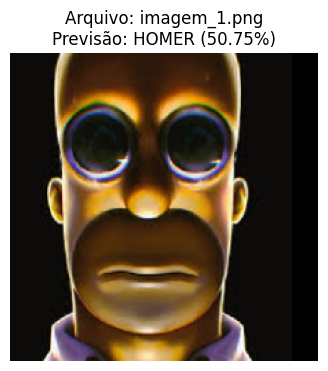

Arquivo: imagem_1.png -> HOMER (50.75%)
------------------------------


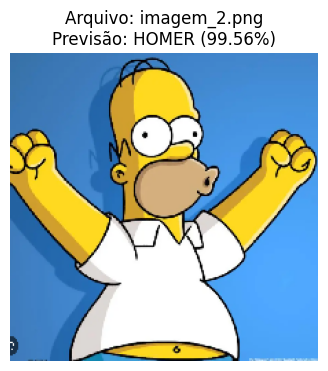

Arquivo: imagem_2.png -> HOMER (99.56%)
------------------------------


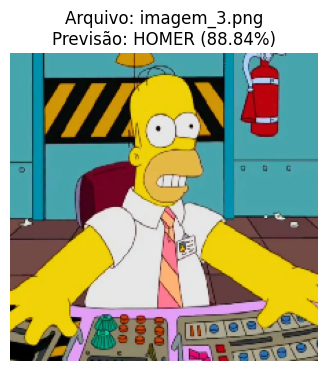

Arquivo: imagem_3.png -> HOMER (88.84%)
------------------------------


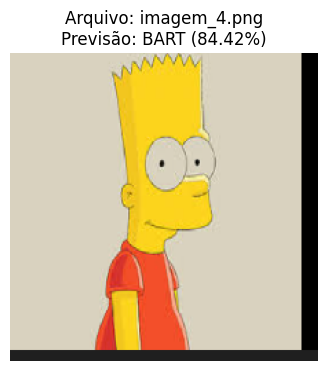

Arquivo: imagem_4.png -> BART (84.42%)
------------------------------


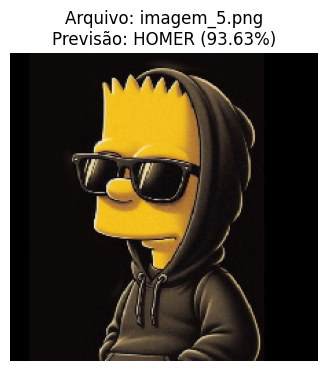

Arquivo: imagem_5.png -> HOMER (93.63%)
------------------------------


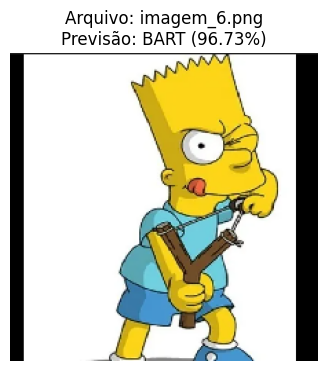

Arquivo: imagem_6.png -> BART (96.73%)
------------------------------


In [17]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

# Caminho da pasta de imagens para previsão
pasta_previsao = '/content/imagens_previsao/'

# Lista todos os arquivos da pasta
arquivos = sorted([f for f in os.listdir(pasta_previsao) if f.endswith(('.png', '.jpg', '.jpeg', '.bmp'))])

print(f'Encontradas {len(arquivos)} imagens para teste.\n')

# Mapeamento de classes
labels = {v: k for k, v in train_generator.class_indices.items()}

# Loop pelas imagens
for filename in arquivos:
    img_path = os.path.join(pasta_previsao, filename)

    # Carregar e processar a imagem
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Fazer a previsão
    prediction = model.predict(img_array, verbose=0)

    # Determinar a classe e confiança
    idx = 1 if prediction[0][0] > 0.5 else 0
    confidencia = prediction[0][0] if idx == 1 else 1 - prediction[0][0]

    # Exibir a imagem e o resultado
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"Arquivo: {filename}\nPrevisão: {labels[idx].upper()} ({confidencia:.2%})")
    plt.axis('off')
    plt.show()

    print(f"Arquivo: {filename} -> {labels[idx].upper()} ({confidencia:.2%})")
    print("-" * 30)

## 5.2 Teste Adicional: Imagens da Web
Utilize a célula abaixo para testar imagens diretamente de URLs da internet. Isso valida a capacidade do modelo de lidar com dados totalmente novos.

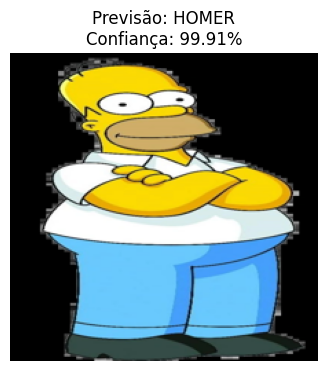

Sucesso ao processar: https://static.wikia.nocookie.net/simpsons/images/b/bd/Homer_Simpson.png


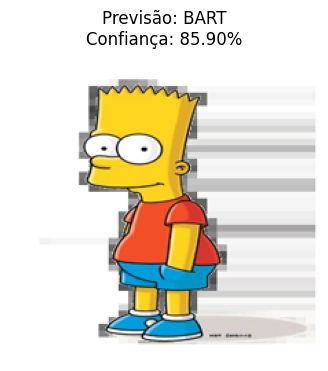

Sucesso ao processar: https://static.wikia.nocookie.net/simpsons/images/6/65/Bart_Simpson.png


In [20]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

# Lista de novas URLs mais estáveis e testadas
urls_para_testar = [
    "https://static.wikia.nocookie.net/simpsons/images/b/bd/Homer_Simpson.png", # Homer (Novo Link)
    "https://static.wikia.nocookie.net/simpsons/images/6/65/Bart_Simpson.png"      # Bart
]

def prever_da_url(url):
    try:
        # Adicionando User-Agent para evitar bloqueios
        headers = {'User-Agent': 'Mozilla/5.0'}
        response = requests.get(url, headers=headers, timeout=15)
        response.raise_for_status()

        img = Image.open(BytesIO(response.content)).convert('RGB')

        # Redimensionamento e Pré-processamento
        img_resized = img.resize((224, 224))
        img_array = image.img_to_array(img_resized)
        img_array = np.expand_dims(img_array, axis=0) / 255.0

        # Predição
        prediction = model.predict(img_array, verbose=0)
        idx = 1 if prediction[0][0] > 0.5 else 0
        confidencia = prediction[0][0] if idx == 1 else 1 - prediction[0][0]

        # Resultado Visual
        plt.figure(figsize=(4,4))
        plt.imshow(img_resized)
        plt.title(f"Previsão: {labels[idx].upper()}\nConfiança: {confidencia:.2%}")
        plt.axis('off')
        plt.show()

        print(f"Sucesso ao processar: {url}")

    except Exception as e:
        print(f"Erro ao processar a URL {url}: {e}")

# Executar novos testes
for url in urls_para_testar:
    prever_da_url(url)

## 6. Conclusão e Revisão dos Resultados

Neste projeto, desenvolvemos um pipeline completo de Deep Learning para a classificação binária dos personagens Homer e Bart Simpson.

### O que foi realizado:
1.  **Dataset e Augmentation:** Utilizamos um conjunto de dados focado nos dois personagens, aplicando técnicas de *Data Augmentation* (rotação, deslocamento e espelhamento) para mitigar o overfitting e aumentar a robustez do modelo.
2.  **Transfer Learning:** Implementamos a arquitetura **MobileNetV2** pré-treinada na ImageNet. Ao congelar as camadas base e adicionar um cabeçalho personalizado (`GlobalAveragePooling2D`, `Dense` com `Dropout`), conseguimos aproveitar a extração de características complexas com um tempo de treinamento reduzido.
3.  **Desempenho:** O modelo alcançou uma acurácia de validação estável em torno de **89%** após 10 épocas.

### Análise das Previsões:
Nos testes realizados com as imagens locais na pasta `imagens_previsao`, o modelo demonstrou:
-   **Alta Confiança no Homer:** A `imagem_2.png` foi identificada como HOMER com **99.56%** de confiança.
-   **Sensibilidade:** A `imagem_1.png` foi classificada como HOMER com **50.75%**, indicando uma classificação correta, porém próxima ao limite de decisão, o que é comum em imagens com fundos complexos ou poses atípicas.

**Resultado Final:** O modelo ainda não está perfeito, e pode ser aperfeiçoado utlizando técnicas como Fine-Tuning e diversidade de dataframe.